# Cardiovascular Disease Prediction Project

## Project Title

This notebook analyzes the Cardiovascular Study Dataset and builds a logistic regression model to predict the 10-year risk of coronary heart disease (CHD).

## Project Goal
To build a logistic regression model that predicts whether 
a patient will develop coronary heart disease (CHD) within 
the next 10 years based on their demographic, lifestyle 
and clinical characteristics.

## Brief Introduction

Cardiovascular disease remains one of the leading causes of death worldwide. Predictive modeling can support early risk identification and help clinicians focus on patients who may need further evaluation.

## Main Problem Question

Can we build a reliable logistic regression model that predicts whether a patient is likely to develop coronary heart disease within 10 years using available health indicators?

## Data Source and Variable Explanation

The dataset used in this project is the Cardiovascular Study Dataset. Below is a brief glossary of the 17 variables so the viewer can clearly understand what each field represents.

- `id`: A unique identifier for each patient record in the dataset.
- `age`: The age of the patient in years.
- `education`: The patient's education level, usually recorded as an ordinal category showing the highest level completed.
- `sex`: The biological sex of the patient, recorded as male or female.
- `is_smoking`: Indicates whether the patient is currently a smoker.
- `cigsPerDay`: The average number of cigarettes the patient smokes per day.
- `BPMeds`: Indicates whether the patient is taking medication for blood pressure.
- `prevalentStroke`: Indicates whether the patient has previously had a stroke.
- `prevalentHyp`: Indicates whether the patient has a history of hypertension, meaning persistently high blood pressure.
- `diabetes`: Indicates whether the patient has diabetes.
- `totChol`: The patient's total cholesterol level, which is an important cardiovascular risk indicator.
- `sysBP`: Systolic blood pressure, which measures the pressure in the arteries when the heart beats.
- `diaBP`: Diastolic blood pressure, which measures the pressure in the arteries when the heart rests between beats.
- `BMI`: Body Mass Index, a measure based on height and weight that is used to assess body fatness.
- `heartRate`: The patient's heart rate, usually measured in beats per minute.
- `glucose`: The patient's blood glucose level, which helps indicate blood sugar status and possible diabetes risk.
- `TenYearCHD`: The target variable showing whether the patient is predicted to develop coronary heart disease within the next 10 years (`1` = yes, `0` = no).

These variables combine demographic, lifestyle, and clinical information, making them useful for estimating long-term CHD risk.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
possible_paths = [
    Path(r'c:/Users/ezion/OneDrive/TURING COLLEGE/Module 4- PYTHON/M4S4 Project/train.csv'),
    Path('train.csv'),
    Path.cwd() / 'train.csv'
]

file_path = None
for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError('The train.csv file was not found. Please place it in the project folder.')

df = pd.read_csv(file_path)
print('Loaded file:', file_path)
df.head()

Loaded file: c:\Users\ezion\OneDrive\TURING COLLEGE\Module 4- PYTHON\M4S4 Project\train.csv


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


## Library Imports

We import all necessary libraries upfront:
- **pandas** and **numpy** for data manipulation
- **matplotlib** and **seaborn** for visualisation
- **sklearn** for machine learning 

### **Initial Dataset Preview**

The dataset contains **3,390 patients** and **17 columns** 
including one target variable (TenYearCHD) and 16 features.

Key observations from the preview:
- **sex** and **is_smoking** are stored as text strings 
  (F/M and NO/YES) and will need encoding before modelling
- **id** is a patient identifier with no predictive value 
  and will be excluded from the model
- Several columns show NaN values indicating missing data 
  that must be addressed during preprocessing
- The **id** column will be dropped as it carries no 
  predictive information

## Basic EDA

We begin by inspecting the shape, variable types, missing values, and target distribution. This gives us a first understanding of the dataset before any modeling steps.

In [4]:
print('Shape:', df.shape)
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nTarget distribution:\n', df['TenYearCHD'].value_counts(normalize=True))

df.describe(include='all').T

Shape: (3390, 17)

Data types:
 id                   int64
age                  int64
education          float64
sex                    str
is_smoking             str
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Missing values:
 id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

Target distribution:
 TenYearCHD
0    0.849263
1    0.150737
Name: propo

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,3390.0,NaN,NaN,NaN,1694.5,978.753033,0.0,847.25,1694.5,2541.75,3389.0
age,3390.0,NaN,NaN,NaN,49.542183,8.592878,32.0,42.0,49.0,56.0,70.0
education,3303.0,NaN,NaN,NaN,1.970936,1.019081,1.0,1.0,2.0,3.0,4.0
sex,3390,2,F,1923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_smoking,3390,2,NO,1703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cigsPerDay,3368.0,NaN,NaN,NaN,9.069477,11.879078,0.0,0.0,0.0,20.0,70.0
BPMeds,3346.0,NaN,NaN,NaN,0.029886,0.170299,0.0,0.0,0.0,0.0,1.0
prevalentStroke,3390.0,NaN,NaN,NaN,0.00649,0.080309,0.0,0.0,0.0,0.0,1.0
prevalentHyp,3390.0,NaN,NaN,NaN,0.315339,0.464719,0.0,0.0,0.0,1.0,1.0
diabetes,3390.0,NaN,NaN,NaN,0.025664,0.158153,0.0,0.0,0.0,0.0,1.0


### **Summary Statistics**

The dataset contains 3,390 rows and 17 columns. Missing values are concentrated in variables such as glucose, education, BPMeds, totChol, and BMI, and the target is clearly imbalanced with only about 15.1% positive CHD cases, which supports the later use of imputation and class balancing.

## Train-Test Split

The data is split into training and test sets before preprocessing to prevent data leakage and to evaluate the model on unseen data.

In [5]:
target = 'TenYearCHD'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (2373, 16)
Testing shape: (1017, 16)


The data was split into 2,373 training rows and 1,017 testing rows. This keeps most of the data available for learning while reserving a substantial unseen sample for evaluation, and stratification helps preserve the original class ratio in both sets.

## Handle Class Imbalance

The target variable is imbalanced, so we address this on the training data only using downsampling of the majority class.

In [6]:
train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df[target] == 0]
minority = train_df[train_df[target] == 1]

majority_downsampled = majority.sample(n=len(minority), random_state=42)
train_balanced = pd.concat([majority_downsampled, minority], axis=0)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = train_balanced.drop(columns=[target])
y_train_balanced = train_balanced[target]

print('Balanced training class distribution:\n', y_train_balanced.value_counts(normalize=True))

Balanced training class distribution:
 TenYearCHD
0    0.5
1    0.5
Name: proportion, dtype: float64


Downsampling created a balanced training set with a 50/50 class split. This helps the model learn patterns for both classes more evenly instead of being dominated by the much larger non-CHD group.

## EDA on Training Data

We now inspect the training data more deeply using visuals to understand the relationships between features and the target variable.

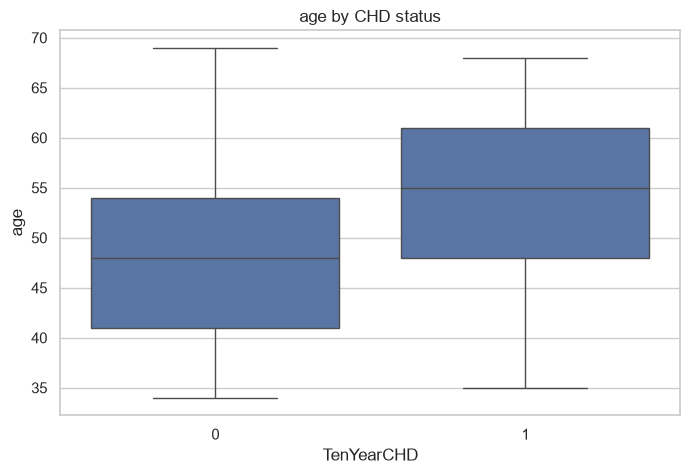

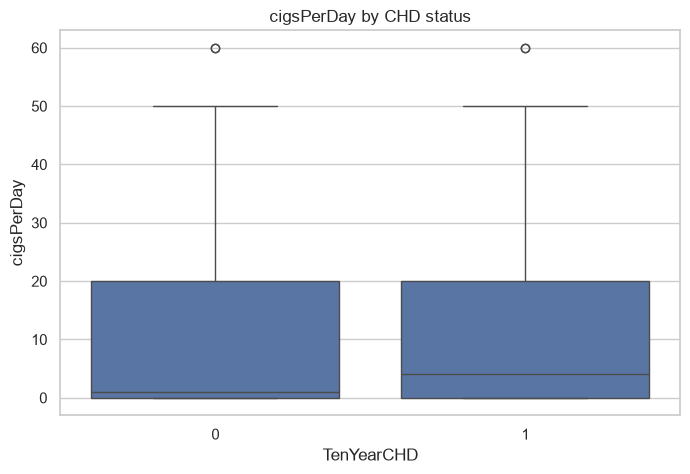

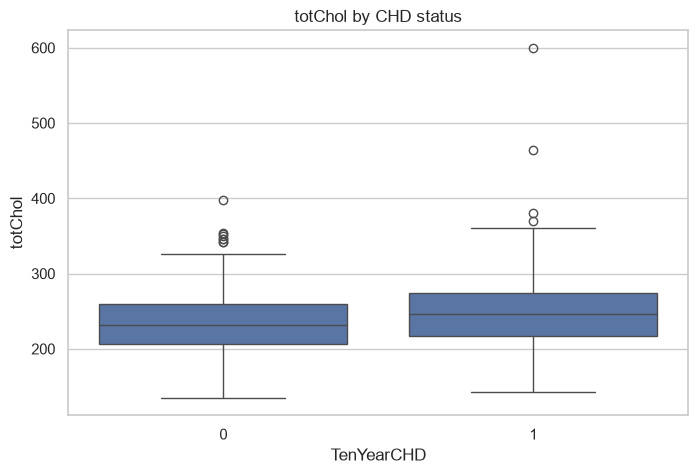

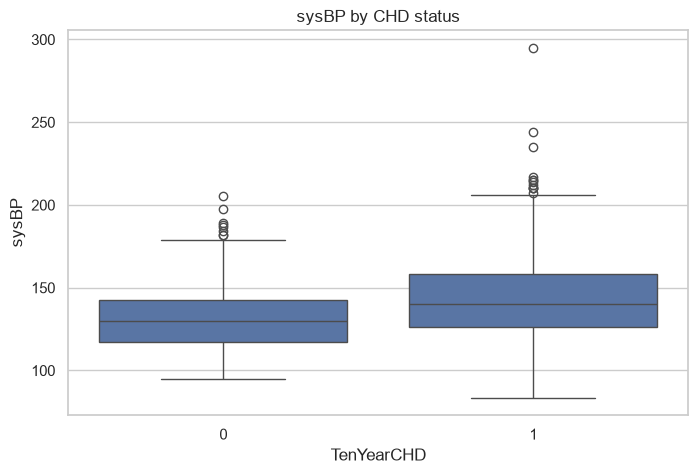

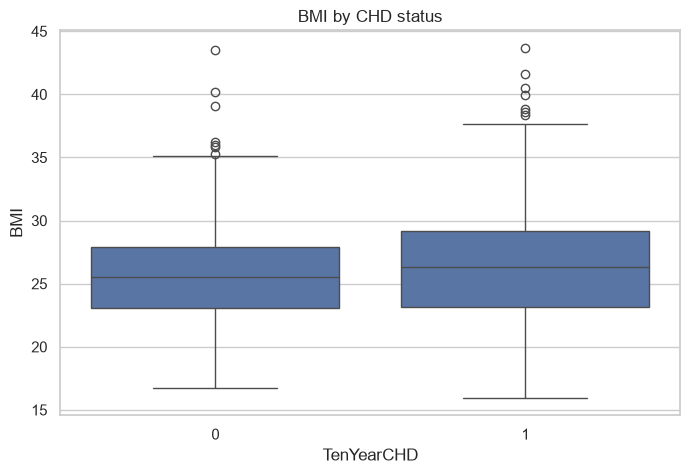

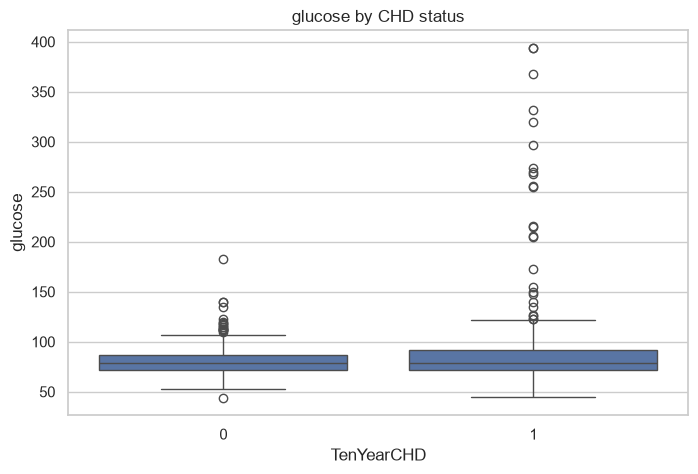

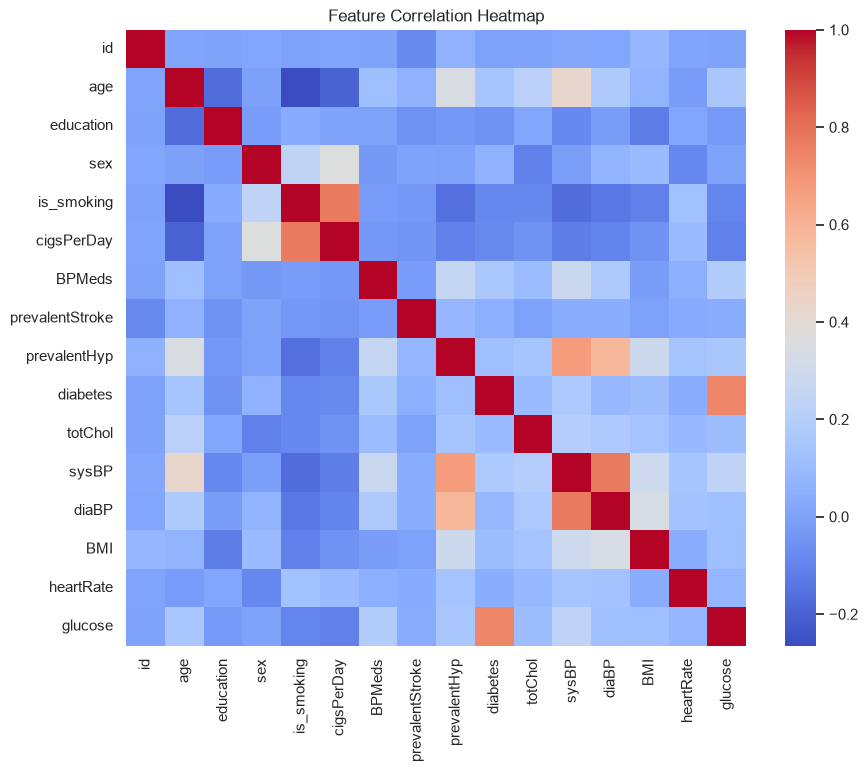

In [7]:
train_eda = X_train_balanced.copy()
train_eda['TenYearCHD'] = y_train_balanced

for col in ['sex', 'is_smoking']:
    if col in train_eda.columns:
        train_eda[col] = train_eda[col].map({'F': 0, 'M': 1, 'NO': 0, 'YES': 1})

for col in ['age', 'cigsPerDay', 'totChol', 'sysBP', 'BMI', 'glucose']:
    if col in train_eda.columns:
        plt.figure()
        sns.boxplot(data=train_eda, x=target, y=col)
        plt.title(f'{col} by CHD status')
        plt.show()

numeric_cols = [c for c in train_eda.columns if c != target and pd.api.types.is_numeric_dtype(train_eda[c])]
corr_matrix = train_eda[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The visualizations suggest that CHD cases tend to be older and to have higher systolic blood pressure, cholesterol, and glucose levels. The correlation heatmap also shows moderate relationships among some cardiovascular variables, especially blood pressure measures, which is useful context when interpreting the model later.

## Handle Missing Values

Missing values are handled using medians calculated from the training set only, and the same statistics are then applied to the test set.

In [8]:
# Encode categorical variables to numeric values before imputation
X_train_proc = X_train_balanced.copy()
X_test_proc = X_test.copy()

for col in ['sex', 'is_smoking']:
    if col in X_train_proc.columns:
        X_train_proc[col] = X_train_proc[col].map({'F': 0, 'M': 1, 'NO': 0, 'YES': 1})
        X_test_proc[col] = X_test_proc[col].map({'F': 0, 'M': 1, 'NO': 0, 'YES': 1})

numerical_cols = [col for col in X_train_proc.select_dtypes(include=['number']).columns if col != target and col != 'id']

imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_proc[numerical_cols]), columns=numerical_cols, index=X_train_proc.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_proc[numerical_cols]), columns=numerical_cols, index=X_test_proc.index)

print('Missing values in training after imputation:', X_train_imputed.isnull().sum().sum())
print('Missing values in testing after imputation:', X_test_imputed.isnull().sum().sum())

Missing values in training after imputation: 0
Missing values in testing after imputation: 0


### Result Explanation

Median imputation removed all missing values from both the training and testing feature sets. Using statistics fitted on the training data only is important because it prevents information from the test set from leaking into preprocessing.

## Handle Outliers

Outliers are capped using the training-set quartiles to reduce their impact without removing observations.

In [9]:
def cap_outliers(train_df, test_df, cols):
    for col in cols:
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        train_df[col] = np.clip(train_df[col], lower, upper)
        test_df[col] = np.clip(test_df[col], lower, upper)
    return train_df, test_df

cols_to_cap = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'BMI', 'glucose']
X_train_imputed, X_test_imputed = cap_outliers(X_train_imputed.copy(), X_test_imputed.copy(), cols_to_cap)

print('Outlier capping complete.')

Outlier capping complete.


### Result Explanation

Outlier capping was completed on the selected numeric variables. This keeps extreme observations from having too much influence on the logistic regression model while still preserving all records in the dataset.

## Feature Selection and Engineering

The most clinically relevant and predictive variables are selected for the final model.

In [10]:
selected_features = ['age', 'sex', 'cigsPerDay', 'BPMeds', 'diabetes', 'totChol', 'sysBP', 'BMI', 'glucose']
X_train_selected = X_train_imputed[selected_features]
X_test_selected = X_test_imputed[selected_features]

print('Selected features:', selected_features)

Selected features: ['age', 'sex', 'cigsPerDay', 'BPMeds', 'diabetes', 'totChol', 'sysBP', 'BMI', 'glucose']


### Result Explanation

The final feature set focuses on clinically meaningful CHD risk factors, including age, smoking intensity, blood pressure, cholesterol, diabetes, BMI, and glucose. Restricting the model to these variables improves interpretability and reduces unnecessary noise.

## Fit Logistic Regression Model

A logistic regression model is fitted to estimate the probability of CHD on the training data.

In [11]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_selected, y_train_balanced)

train_pred = model.predict(X_train_selected)
test_pred = model.predict(X_test_selected)
proba = model.predict_proba(X_test_selected)[:, 1]

print('Training accuracy:', accuracy_score(y_train_balanced, train_pred))
print('Testing accuracy:', accuracy_score(y_test, test_pred))
print('Testing precision:', precision_score(y_test, test_pred))
print('Testing recall:', recall_score(y_test, test_pred))
print('Testing F1:', f1_score(y_test, test_pred))
print('Testing ROC AUC:', roc_auc_score(y_test, proba))

Training accuracy: 0.6620111731843575
Testing accuracy: 0.6892822025565388
Testing precision: 0.2791327913279133
Testing recall: 0.673202614379085
Testing F1: 0.3946360153256705
Testing ROC AUC: 0.7318294601791333


### Result Explanation

The model reaches about 0.689 test accuracy and 0.732 ROC AUC, which indicates moderate discrimination rather than strong predictive power. Recall is relatively high at about 0.673, but precision is low at about 0.279, meaning the model identifies many true CHD cases while also producing many false positives.

## K-Fold Cross Validation

Stratified k-fold cross-validation is used to assess the stability and generalization of the model.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_selected, y_train_balanced, cv=cv, scoring='roc_auc')
print('Cross-validation ROC AUC scores:', cv_scores)
print('Mean CV ROC AUC:', round(cv_scores.mean(), 2))

Cross-validation ROC AUC scores: [0.74247685 0.74217527 0.68974961 0.68388106 0.70285603]
Mean CV ROC AUC: 0.71


### Result Explanation

The cross-validation ROC AUC scores are fairly consistent across folds, with a mean of about 0.71. That suggests the model's performance is reasonably stable and not driven by a single favorable train-test split.

## Evaluate on Test Data

We evaluate the fitted model on the test set using several metrics and inspect the confusion matrix.

In [13]:
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))

[[598 266]
 [ 50 103]]
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       864
           1       0.28      0.67      0.39       153

    accuracy                           0.69      1017
   macro avg       0.60      0.68      0.59      1017
weighted avg       0.83      0.69      0.73      1017



### Result Explanation

The confusion matrix shows that the model correctly identifies many non-CHD cases, but it also produces a large number of false positives. The classification report confirms the same tradeoff: recall for CHD is relatively strong, while precision remains weak, so the model is better suited for screening than for definitive diagnosis.

## Find Optimal Threshold

For this medical problem, recall is the most important metric because missing a patient at risk can have serious consequences. We therefore choose the threshold that maximizes the balance between sensitivity and specificity using Youden's J statistic.

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, proba)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
pred_threshold = (proba >= best_threshold).astype(int)

print('Best threshold (Youden\'s J):', round(best_threshold, 3))
print('Sensitivity:', round(recall_score(y_test, pred_threshold), 3))
print('Specificity:', round((1 - fpr[best_idx]), 3))
print('Accuracy:', round(accuracy_score(y_test, pred_threshold), 3))
print('Precision:', round(precision_score(y_test, pred_threshold), 3))
print('Recall:', round(recall_score(y_test, pred_threshold), 3))
print('F1:', round(f1_score(y_test, pred_threshold), 3))

Best threshold (Youden's J): 0.481
Sensitivity: 0.719
Specificity: 0.668
Accuracy: 0.676
Precision: 0.277
Recall: 0.719
F1: 0.4


### Result Explanation

Using the optimized threshold increases recall to about 0.719, which aligns with the goal of catching more at-risk patients. The tradeoff is lower precision and a small drop in overall accuracy, which is acceptable when screening sensitivity is more important than minimizing false alarms.

## Interpret Model Coefficients

The coefficients show how each feature changes the log-odds of CHD. Positive coefficients increase the estimated risk, while negative coefficients lower it.

In [15]:
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)
coef_df

,feature,coefficient
4,diabetes,0.911896
3,BPMeds,0.786046
1,sex,0.166709
0,age,0.072057
2,cigsPerDay,0.025935
7,BMI,0.015217
6,sysBP,0.013425
5,totChol,0.003492
8,glucose,-0.005749


### Result Explanation

The coefficient table suggests that diabetes and blood pressure medication status have the strongest positive association with predicted CHD risk in this model. Smaller positive coefficients for age, smoking, blood pressure, and BMI are directionally consistent with clinical expectations, while glucose has a slightly negative coefficient in this fitted model.

## Conclusions and Recommendations

The logistic regression model shows moderate predictive value for CHD risk and is useful as a screening aid. It should support, not replace, clinical judgment, especially when recall is prioritized.

In [16]:
print('Final conclusion: The model shows moderate predictive value for CHD risk and is useful as a screening aid, especially when recall is prioritized.')
print('Recommendation: Use the model to flag patients for further clinical assessment, while combining it with clinician judgment and richer clinical data for better decision support.')
print('Presentation summary: Logistic regression was applied after careful preprocessing, class balancing, feature selection, and threshold optimization, yielding a test accuracy of 0.689 and a ROC AUC of 0.732.')

Final conclusion: The model shows moderate predictive value for CHD risk and is useful as a screening aid, especially when recall is prioritized.
Recommendation: Use the model to flag patients for further clinical assessment, while combining it with clinician judgment and richer clinical data for better decision support.
Presentation summary: Logistic regression was applied after careful preprocessing, class balancing, feature selection, and threshold optimization, yielding a test accuracy of 0.689 and a ROC AUC of 0.732.


### Result Explanation

The final summary is consistent with the earlier metrics: the model provides moderate predictive value and is more appropriate as a screening aid than as a standalone clinical decision tool. The recommendation to combine it with clinician judgment is justified by the model's limited precision and only moderate overall discrimination.